# Astigmatic Beam Shaping — Progressive Constraint Tightening

**Problem**: Focus a circular Gaussian beam (λ=800 nm, w₀=1.0 mm) to an astigmatic
waist using a fixed 3-lens combination (**Spherical + CylX + CylY**).

| Parameter | Value |
|-----------|-------|
| Wavelength λ | 800 nm |
| Input waist w₀ | 1.0 mm (circular) |
| Target position z | 500 mm |
| Target w_x | 120 µm |
| Target w_y | 400 µm |
| w_x tolerance | \|Δw_x\| / w_x ≤ 5% |
| w_y tolerance | \|Δw_y\| / w_y ≤ 5% |
| Waist position tolerance | \|Δz\| / z_R ≤ 0.2 |

**Lens types**

| Type | x-axis | y-axis |
|------|--------|--------|
| `spherical` | ThinLens(f) | ThinLens(f) |
| `cyl_x` | ThinLens(f) | identity |
| `cyl_y` | identity | ThinLens(f) |

**Strategy**: Progressive constraint tightening.

| Step | Constraints |
|------|-------------|
| 1 | f ∈ (−10000, 10000) mm, z ≤ 480 mm, no sep. |
| 2 | + sep ≥ 20 mm, Δf = 5 mm |
| 3 | + \|f\| ∈ [30, 1000] mm |

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from gbeampro import GaussBeam, OpticalSystem, Propagation
from gbeampro.optimize import waist_operands, optimize_astigmatic, build_xy_systems
import gbeampro.plot as gplot
import gbeampro.analysis as ga
import gbeampro
print('gbeampro version:', gbeampro.__version__)

gbeampro version: 2.0.0


## Problem Setup

In [2]:
WL        = 0.800   # µm
W0        = 1.0     # mm
Z_TARGET  = 500.0   # mm
WX_TARGET = 0.120   # mm
WY_TARGET = 0.400   # mm
TOL_WX = 0.05  # PASS if |Δw_x| / w_x ≤ this
TOL_WY = 0.05  # PASS if |Δw_y| / w_y ≤ this
TOL_dz_over_zR = 0.2  # PASS if |Δz| / z_R ≤ this

LENS_TYPES = ['spherical', 'cyl_x', 'cyl_y']

beam = GaussBeam.from_waist(wl_um=WL, w0_mm=W0)
print(beam)

traj0 = OpticalSystem().add(Propagation(Z_TARGET)).trace(beam, dz=1.0)
print(f'\nWithout optics at z={Z_TARGET} mm:  w = {traj0[-1].w_mm*1e3:.1f} µm')
print(f'Targets:  w_x = {WX_TARGET*1e3:.0f} µm,  w_y = {WY_TARGET*1e3:.0f} µm')

operands = waist_operands(
    z_mm=Z_TARGET, wx_mm=WX_TARGET, wy_mm=WY_TARGET,
    size_weight=1.0,
    curvature_weight_x=1.0,
    curvature_weight_y=1.0,
)
print(f'\nMerit function operands:')
for op in operands:
    print(f'  {op.type:<4}  target={op.target:.4g}  weight={op.weight:.3g}')

GaussBeam(wl_um=0.8, n=1.0, z_mm=0.00000, R_mm=inf, w_mm=1.00000)
  q = 0.00000e+00-3.92699e+03j  theta = 0.2546 mrad

Without optics at z=500.0 mm:  w = 1008.1 µm
Targets:  w_x = 120 µm,  w_y = 400 µm

Merit function operands:
  wx    target=0.12  weight=1
  wy    target=0.4  weight=1
  cvx   target=0  weight=1
  cvy   target=0  weight=1


## Helper Functions

In [3]:
def print_specs(result):
    print("Lens system specs:")
    print(f"{'#':>2}  {'Type':<12}  {'z (mm)':>10}  {'f (mm)':>10}  {'|f| (mm)':>10}")
    print('   ' + '-' * 48)
    for i, s in enumerate(result.specs, 1):
        ftype = 'conv.' if s['f_mm'] > 0 else 'div.'
        print(f"{i:>2}  {s['type']:<12}  {s['z_mm']:>10.2f}  {s['f_mm']:>10.2f}  "
              f"{abs(s['f_mm']):>10.2f}  ({ftype})")
    if len(result.specs) > 1:
        seps = [result.specs[i+1]['z_mm'] - result.specs[i]['z_mm']
                for i in range(len(result.specs)-1)]
        print(f'  separations: {[f"{d:.1f} mm" for d in seps]}')

def verify_waists(result):
    print("\nVerification of waists at target plane:")
    Z_EXTRA = Z_TARGET + 200.0
    sx, sy = build_xy_systems(beam, result.specs, Z_EXTRA)
    for axis, sys_, w_target, tol_w in [
        ('x', sx, WX_TARGET, TOL_WX),
        ('y', sy, WY_TARGET, TOL_WY),
    ]:
        waists = ga.find_waists(sys_.trace(beam, dz=1.0))
        print(f'{axis}-axis:')
        for w in waists:
            zr = ga.rayleigh_range(w)
            dz_over_zr = (w.z_mm - Z_TARGET) / zr
            w_err = (w.w_mm - w_target) / w_target
            pass_w  = abs(w_err)        <= tol_w
            pass_dz = abs(dz_over_zr)   <= TOL_dz_over_zR
            flag_w  = 'PASS' if pass_w  else 'FAIL'
            flag_dz = 'PASS' if pass_dz else 'FAIL'
            print(f'  z={w.z_mm:.1f} mm  Δz/z_R={dz_over_zr:+.3f} [{flag_dz}]  '
                  f'w₀={w.w_mm*1e3:.2f} µm  Δw/w={w_err:+.3f} [{flag_w}]  '
                  f'2z_R={2*zr:.1f} mm')
        if not waists:
            print('  (none found in range)')

def plot_result(result, title):
    Z_EXTRA = Z_TARGET + 100.0
    sx, sy = build_xy_systems(beam, result.specs, Z_EXTRA)
    traj_x = sx.trace(beam, dz=1.0)
    traj_y = sy.trace(beam, dz=1.0)
    fig, ax = plt.subplots(figsize=(12, 4))
    gplot.plot_system(sx, traj_x, ax, label=f'x-axis  ({WX_TARGET*1e3:.0f} µm)')
    gplot.plot_system(sy, traj_y, ax, label=f'y-axis  ({WY_TARGET*1e3:.0f} µm)')
    ax.axvline(Z_TARGET, color='k', ls=':', lw=1.2)
    ax.scatter([Z_TARGET, Z_TARGET], [WX_TARGET*1e3, WY_TARGET*1e3],
               color='k', zorder=6, s=60, label='targets')
    ax.set_title(title)
    plt.tight_layout()

## Step 1: Theoretical Baseline

Any focal length allowed, lenses placed anywhere in [0, 480 mm] (20 mm margin before target).
No separation constraint.

In [4]:
r1 = optimize_astigmatic(
    beam, LENS_TYPES, operands,
    f_bounds=(-1000, 1000),
    z_max_mm=450.0,
    min_lens_sep_mm=0.0,
    algorithm='de',
    maxiter=2000, popsize=20, seed=42,
)
print(f'merit = {r1.merit:.2e}')
print_specs(r1)

[optimize_astigmatic] elapsed: 84.59 s
merit = 1.26e-03
Lens system specs:
 #  Type              z (mm)      f (mm)    |f| (mm)
   ------------------------------------------------
 1  spherical           0.00      734.05      734.05  (conv.)
 2  cyl_x             127.99     1000.00     1000.00  (conv.)
 3  cyl_y             450.00     -340.90      340.90  (div.)
  separations: ['128.0 mm', '322.0 mm']



Verification of waists at target plane:
x-axis:
  z=501.0 mm  Δz/z_R=+0.019 [PASS]  w₀=115.81 µm  Δw/w=-0.035 [PASS]  2z_R=105.3 mm
y-axis:
  z=501.0 mm  Δz/z_R=+0.002 [PASS]  w₀=402.31 µm  Δw/w=+0.006 [PASS]  2z_R=1271.2 mm


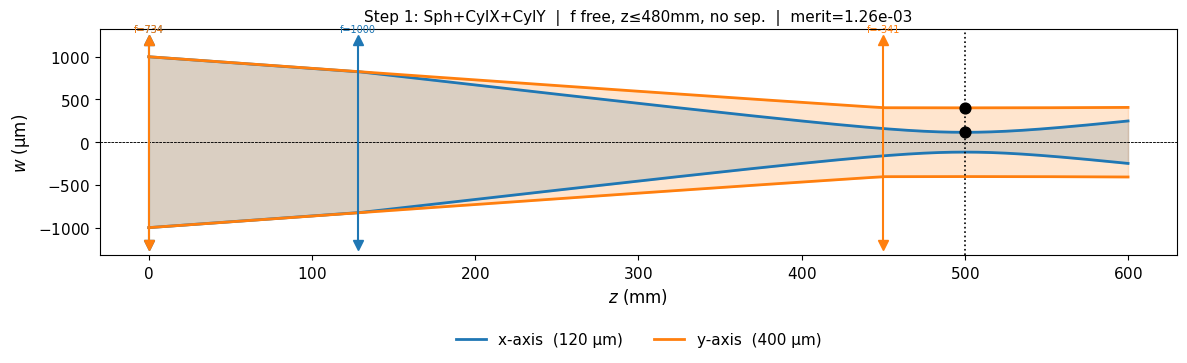

In [5]:
plot_result(r1,
    f'Step 1: Sph+CylX+CylY  |  f free, z≤480mm, no sep.  |  merit={r1.merit:.2e}')
verify_waists(r1)

## Step 2: Add Focal Length Range Constraint

Further restrict to **|f| ∈ [30, 500] mm** — standard catalog range.
All Step 2 constraints remain active.

In [6]:
r2 = optimize_astigmatic(
    beam, LENS_TYPES, operands,
    f_abs_bounds=(30, 500),
    f_step_mm=10.0,
    z_max_mm=450.0,
    min_lens_sep_mm=20.0,
    algorithm='de',
    maxiter=2000, popsize=20, seed=42,
)
print(f'merit = {r2.merit:.2e}')
print_specs(r2)

[optimize_astigmatic] elapsed: 69.81 s
merit = 8.32e-05
Lens system specs:
 #  Type              z (mm)      f (mm)    |f| (mm)
   ------------------------------------------------
 1  spherical         116.89      310.00      310.00  (conv.)
 2  cyl_x             274.56     -440.00      440.00  (div.)
 3  cyl_y             298.93     -140.00      140.00  (div.)
  separations: ['157.7 mm', '24.4 mm']



Verification of waists at target plane:
x-axis:
  z=501.0 mm  Δz/z_R=+0.017 [PASS]  w₀=119.69 µm  Δw/w=-0.003 [PASS]  2z_R=112.5 mm
y-axis:
  z=496.0 mm  Δz/z_R=-0.007 [PASS]  w₀=397.42 µm  Δw/w=-0.006 [PASS]  2z_R=1240.5 mm


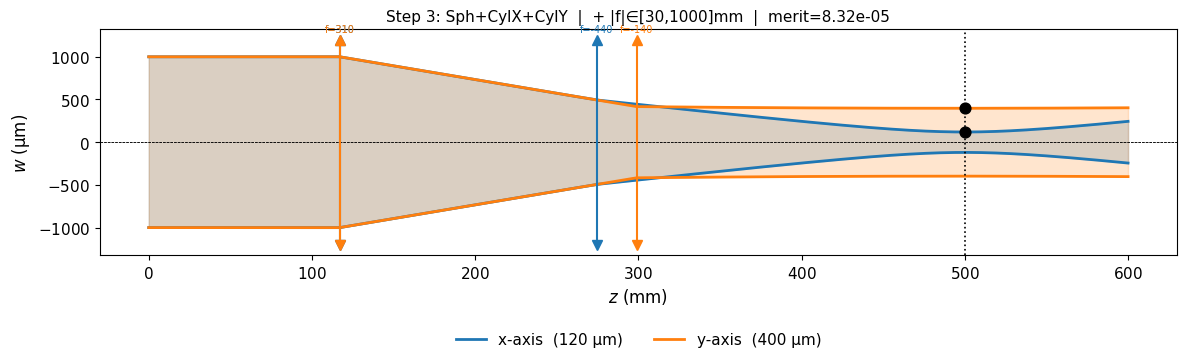

In [7]:
plot_result(r2,
    f'Step 3: Sph+CylX+CylY  |  + |f|∈[30,1000]mm  |  merit={r2.merit:.2e}')
verify_waists(r2)

## Summary

In [8]:
print(f"{'Step':<6}  {'Constraints':<50}  {'merit':>10}")
print('-' * 70)
for step, desc, res in [
    ('1', 'f free, z≤480mm, no sep.',                        r1),
    ('2', '+ |f|∈[30,1000]mm',                               r2),
]:
    print(f'{step:<6}  {desc:<50}  {res.merit:>10.2e}')

print()
print('Step 2 (most realistic):')
sx2, sy2 = build_xy_systems(beam, r2.specs, Z_TARGET + 200)
print('=== x-axis ===')
print(sx2.summary(beam))

print('=== y-axis ===')
print(sy2.summary(beam))

print_specs(r2)

verify_waists(r2)

Step    Constraints                                              merit
----------------------------------------------------------------------
1       f free, z≤480mm, no sep.                              1.26e-03
2       + |f|∈[30,1000]mm                                     8.32e-05

Step 2 (most realistic):
=== x-axis ===


OpticalSystem trace  [wl=0.8 um]
   #  Type                   z (mm)     w (um)      R (mm)   th (urad)
------------------------------------------------------------------------
   0  --- input ---           0.000    1000.00         inf      254.65
   1  Propagation           116.886    1000.44   1.321e+05      254.54
   2  ThinLens              116.886    1000.44  -3.107e+02      254.54
   3  Propagation           274.555     494.43  -1.551e+02      515.03
   4  ThinLens              274.555     494.43  -2.395e+02      515.03
   5  Propagation           298.932     444.28  -2.168e+02      573.17
   6  Propagation           700.000     442.09   2.158e+02      576.01
Beam waists:  z=500.001 mm (2w0=239.3 um)
=== y-axis ===


OpticalSystem trace  [wl=0.8 um]
   #  Type                   z (mm)     w (um)      R (mm)   th (urad)
------------------------------------------------------------------------
   0  --- input ---           0.000    1000.00         inf      254.65
   1  Propagation           116.886    1000.44   1.321e+05      254.54
   2  ThinLens              116.886    1000.44  -3.107e+02      254.54
   3  Propagation           274.555     494.43  -1.551e+02      515.03
   4  Propagation           298.932     416.90  -1.315e+02      610.82
   5  ThinLens              298.932     416.90  -2.154e+03      610.82
   6  Propagation           700.000     418.47   2.086e+03      608.53
Beam waists:  z=495.491 mm (2w0=794.8 um)
Lens system specs:
 #  Type              z (mm)      f (mm)    |f| (mm)
   ------------------------------------------------
 1  spherical         116.89      310.00      310.00  (conv.)
 2  cyl_x             274.56     -440.00      440.00  (div.)
 3  cyl_y             298.93     -140

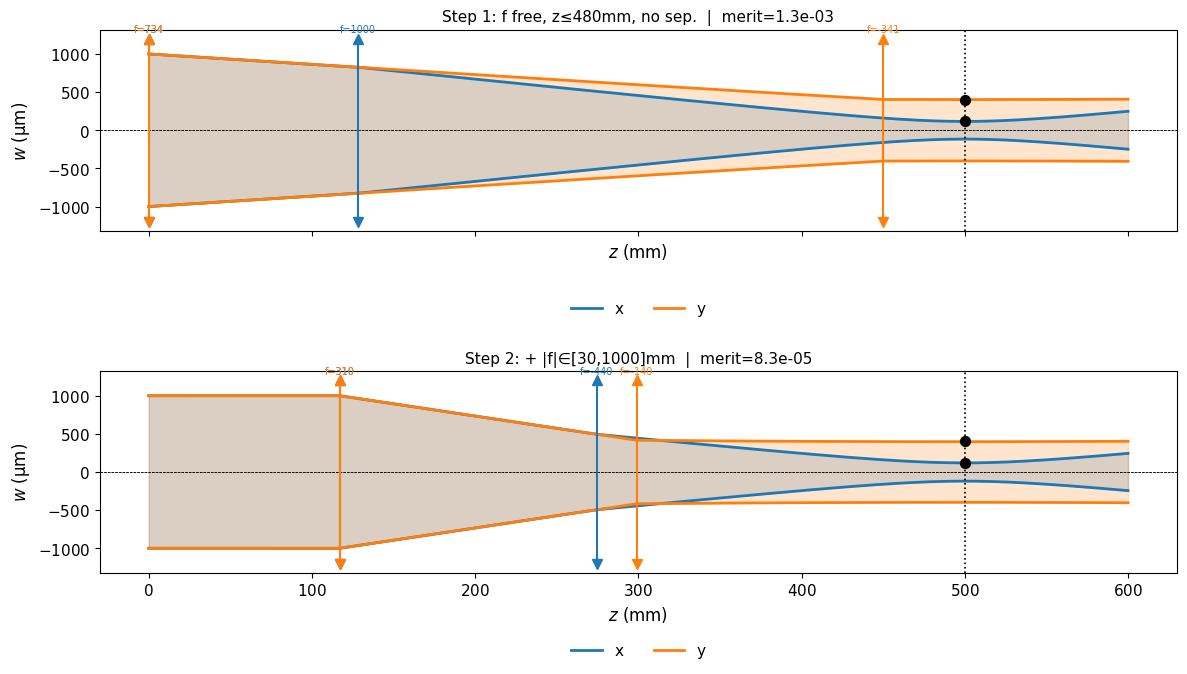

In [9]:
Z_EXTRA = Z_TARGET + 100.0
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

for ax, (res, label) in zip(axes, [
    (r1, 'Step 1: f free, z≤480mm, no sep.'),
    (r2, 'Step 2: + |f|∈[30,1000]mm'),
]):
    sx, sy = build_xy_systems(beam, res.specs, Z_EXTRA)
    gplot.plot_system(sx, sx.trace(beam, dz=1.0), ax, label=f'x')
    gplot.plot_system(sy, sy.trace(beam, dz=1.0), ax, label=f'y')
    ax.axvline(Z_TARGET, color='k', ls=':', lw=1.2)
    ax.scatter([Z_TARGET, Z_TARGET], [WX_TARGET*1e3, WY_TARGET*1e3],
               color='k', zorder=6, s=50)
    ax.set_title(f'{label}  |  merit={res.merit:.1e}')

plt.tight_layout()